<a href="https://colab.research.google.com/github/irenemarincastilla/Simulaci-n-Cadenas-de-Markov/blob/main/Irene_MC_simulaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = pi_sup_1.shape[0]

  # Paso 1: crear un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps))

  # Paso 2: simulamos el estado inicial para cada una de las n_samples trayectorias y guárdalo en la primera columna del array trayectorias.
  trayectorias[:, 0] = np.random.choice(m, n_samples, p=pi_sup_1) #los argumentos de la función son los valores que toma, el número de valores que devuelve (el tamaño del vector resultante) y la probabilidad de tomar cada uno

  # Paso 3: iterando sobre n_samples y n_steps, rellena todo el array "trayectorias". Puedes usar de nuevo np.random.choice
  for step in range(1, n_steps): #empezamos en el 1 porque ya tenemos el primer estado, que lo hemos generado anteriormente
    for sample in range(0, n_samples):
      trayectorias[sample, step] = np.random.choice(m, p=P[int(trayectorias[sample, step-1])])

  return trayectorias

A continuación vamos a hacer una versión más eficiente de esta función, eliminando uno de los bucles ```for``` (concretamente, el que recorre ```n_samples```). El otro bucle, el que recorre ```n_steps```, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo. Pero la dimensión sobre ```n_samples``` sí que es conceptualmente paralelizable.

In [ ]:
def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  m = pi_sup_1.shape[0]

  trayectorias = np.zeros((n_samples, n_steps))

  trayectorias[:, 0] = np.random.choice(m, n_samples, p=pi_sup_1) #los primeros pasos son iguales que en la anterior


  # Paso 3: iterando sobre n_steps, utiliza numpy (en vez de for) para generar conjuntamente todas las trayectorias.
  # Recuerda (o piensa o busca) cómo funciona np.random.choice a partir de la generación de un número aleatorio que sigue una uniforme en el intervalo (0,1).
  # Implementa ese proceso manualmente con arrays de numpy. En particular puedes mirar np.argmax(), que puede usarse para proporcionar el primer índice que cumple cierta condición.


  for step in range(1, n_steps):
      # Estados actuales de cada trayectoria
      estados_actuales = trayectorias[:, step - 1].astype(int) #como lo voy a usar como índices para los elementos de P, los "convierto" en enteros

      # Como antes, vamos a usar la fila de P correspondiente a cada trayectoria
      probs = P[estados_actuales, :]

      # Distribución acumulada por fila, shape, ya que con lo que vamos a trabajar son con los números aleatorios de [0 a 1].
      cum_probs = np.cumsum(probs, axis=1)

      # Un número uniforme por trayectoria, shape (n_samples, 1)
      u = np.random.uniform(size=(n_samples, 1))

      # Primer estado donde u < cumsum → shape (n_samples,)
      trayectorias[:, step] = np.argmax(u < cum_probs, axis=1)
  return trayectorias

Una vez implementadas ambas opciones, utiliza las siguientes celdas para evaluar su eficiencia.

El comando ```%%timeit``` al principio de una celda hace que se ejecute varias veces y se devuelva un resumen de tiempo de ejecución (media y desviación típica sobre diferentes pruebas).

En mi ejecución, la versión eficiente ha resultado ser más de 250 veces más rápida.

In [ ]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

1.82 s ± 1.03 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

5.56 ms ± 990 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Por último en esta sección, genera seis trayectorias durante 50 pasos y haz una visualización similar a la diapositiva 24.

Para ello utiliza la función ```plt.step```.

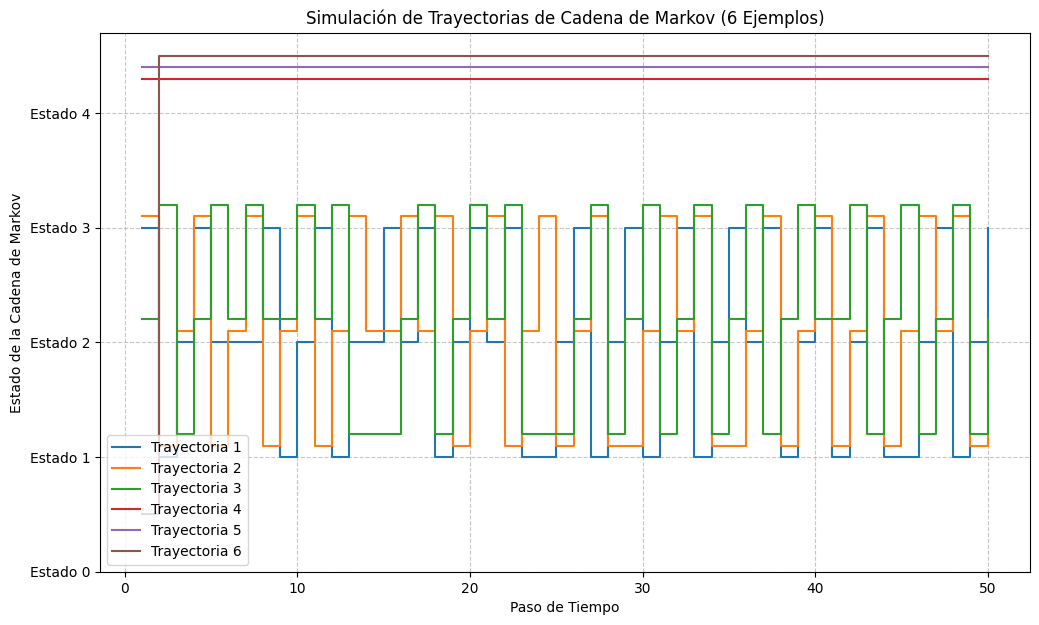

In [ ]:
# COMPLETAR: haz una visualización similar a la diapositiva 24.

# Definimos las variables como las de la diapositiva:

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])


num_trayectorias_plot = 6
num_steps_plot = 50

#voy a añadir un "ruido" para que no se solapen las trayectorias y poder diferenciarlas:
eps = 0.1

ruido = eps * np.arange(num_trayectorias_plot)



# Simulamos las trayectorias utilizando la función eficiente:

trayectorias_plot = simular_trayectorias_effic(P, pi_sup_1, num_trayectorias_plot, num_steps_plot)

# Sacamos las trayectorias
plt.figure(figsize=(12, 7))
for i in range(num_trayectorias_plot):
    plt.step(range(1, num_steps_plot +1), trayectorias_plot[i, :] + ruido[i], where='post', label=f'Trayectoria {i+1}')

    #empiezo en 1 los valores de x
    #where = post es para que el salto sea después
    #con este for muevo los valores de x para graficar cada columna de la matriz de trayectorias (es decir el paso i para cada una de las trayectorias)

plt.title('Simulación de Trayectorias de Cadena de Markov (6 Ejemplos)')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Estado de la Cadena de Markov')
plt.yticks(np.arange(P.shape[0]), [f'Estado {j}' for j in range(P.shape[0])]) # Label states correctly
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 2. Distribución marginal de una MC

Vamos a definir una función que nos permita obtener la distribución marginal de una MC en un instante dado.

In [ ]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.

  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """
  # Paso único: recuerda cómo se calcula la marginal en el instante n en base al producto matricial.
  # El producto matricial entre dos arrays de numpy A y B se denota con @, es decir, A @ B
  # También puedes buscar cómo calcular la k-ésima potencia de una matriz: A^k (mira np.linalg.matrix_power)
  marginal =  pi_sup_1 @ np.linalg.matrix_power(P, n - 1)
  return marginal

Utiliza la función anterior para visualizar empíricamente que la distribución marginal de nuestra MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Es decir, reproduce las imágenes de las diapositivas 61 y 63.

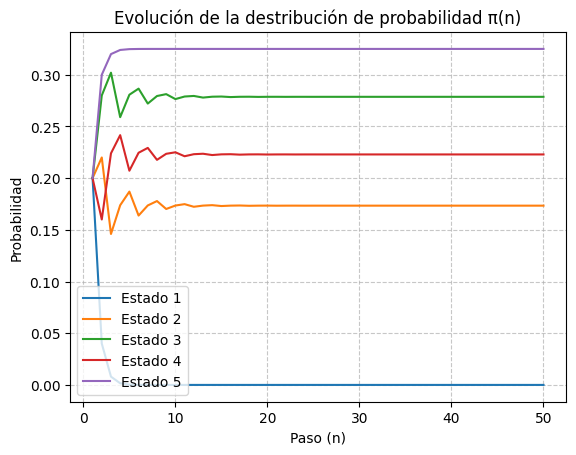

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

marginales = np.array([obtener_marginal(P, pi_sup_1, n) for n in range(1, 51)]).T
# marginales es una matriz 5 x 50: 5 estados, 50 pasos
# Cada fila es la marginal de uno de los estados

#la represento:
plt.figure()
for estado in range(P.shape[0]):
    plt.plot(range(1, 51), marginales[estado, :], label=f'Estado {estado + 1}')

plt.title('Evolución de la destribución de probabilidad π(n)')
plt.xlabel('Paso (n)')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Diapositiva 63: marginal con π(1)=(0,0,0,0,1)

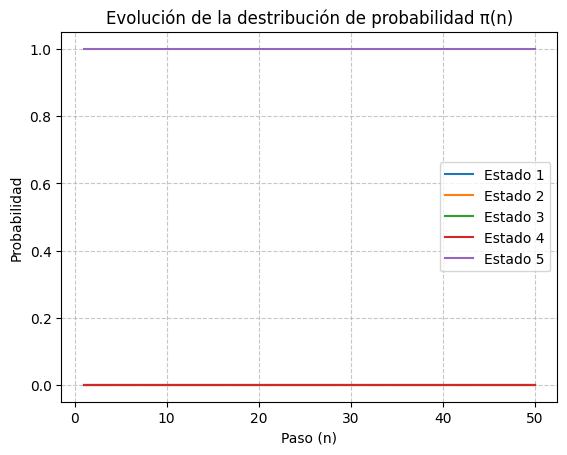

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0,0,0,0,1])

marginales = np.array([obtener_marginal(P, pi_sup_1, n) for n in range(1, 51)]).T
# marginales es una matriz 5 x 50: 5 estados, 50 pasos
# Cada fila es la marginal de uno de los estados

#la represento:
plt.figure()
for estado in range(P.shape[0]):
    plt.plot(range(1, 51), marginales[estado, :], label=f'Estado {estado + 1}')

plt.title('Evolución de la destribución de probabilidad π(n)')
plt.xlabel('Paso (n)')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3. Diagrama de transición de estados

Vamos a definir una función para dibujar el diagrama de transición de estados de una MC. Como hemos visto, esta es una de las formas más habituales de visualizar una MC.

Trata de entender la siguiente función (al menos sus argumentos de entrada y su funcionamiento general, hay detalles sobre los "edge_labels" que son menos relevantes para nosotros).

In [ ]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure()

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

Usa la función anterior para dibujar el diagrama de transición de estados de nuestra MC. Esta es una figura que hemos visto repetidamente (la primera vez en la diapositiva 27).

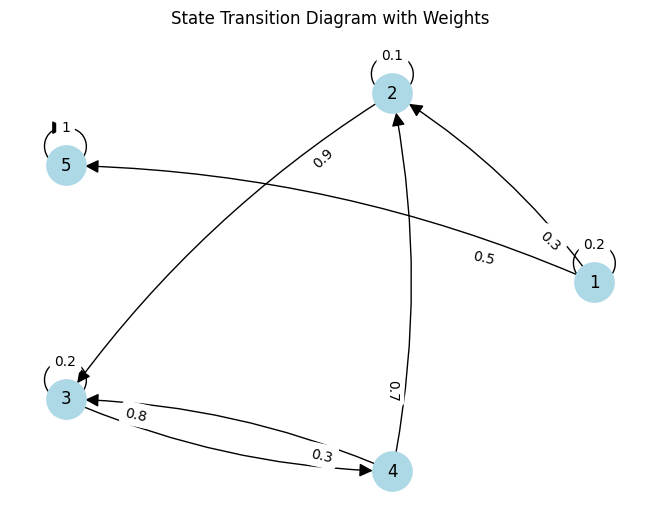

In [ ]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

states = [1, 2, 3, 4, 5]

dibujar_diagrama_transicion(P, states)

## 4. Teorema de convergencia de MCs

En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.

Vamos a empezar por definir una función que nos permita visualizar la evolución de la distribución marginal de una MC. Este tipo de gráfica ya la habíamos obtenido en la sección 3, cuando se reprodujeron las diapositivas 61 y 63. No obstante, aquí se encapsula en una función y se hace de manera más eficiente que allí:

In [ ]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_steps: instante de tiempo hasta el que se quiere visualizar. Int.

  Output:
  La función no devuelve nada por "return", simplemente realiza un gráfico.
  """

  # Paso 1: crear un array con shape (m, n_steps) y rellenarlo con las marginales en cada paso.
  m = P.shape[0]
  marginales = np.zeros((m, n_steps))
  marginales[:, 0] = pi_sup_1 # doy a mano el primer valor de la marginal

  for step in range(1, n_steps):
    marginales[:, step] = marginales[:, step - 1] @ P

  #esto es mas eficiente que lo anterior porque usas el paso anterior para obtener el siguiente, no tienes que estar calculando la potencia n-ésima de P para cada paso



  # Paso 2: Dibujar la trayectoria de cada componente de la marginal.
  #esta parte es igual que en el anterior
  for estado in range(m):
      plt.plot(range(1, n_steps + 1), marginales[estado, :], label=f'State {estado + 1}')

  plt.title('Evolution of Probability Distribution π(n)')
  plt.xlabel('Step (n)')
  plt.ylabel('Probability')
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.show()

Comprueba que una MC con esta matriz de transición es unicadenal (de hecho es irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completa la celda y luego ejecútala varias veces para comprobar que siempre se converge al mismo límite.

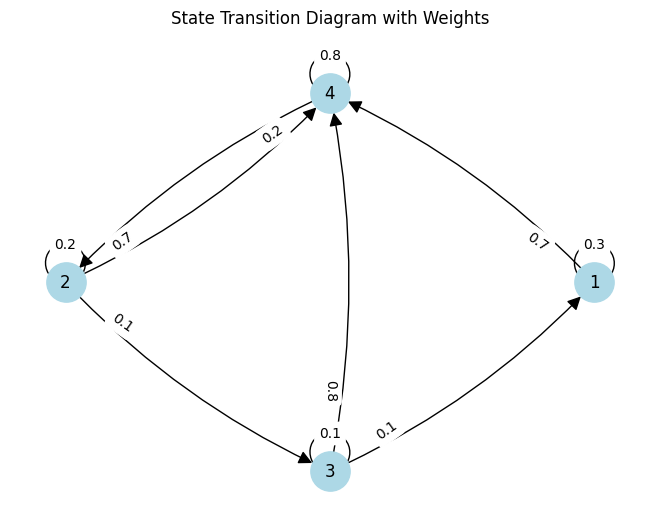

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Comprueba que una MC con esta matriz de transición es unicadenal (de hecho es irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completa la celda y luego ejecútala varias veces para comprobar que siempre se converge al mismo límite.

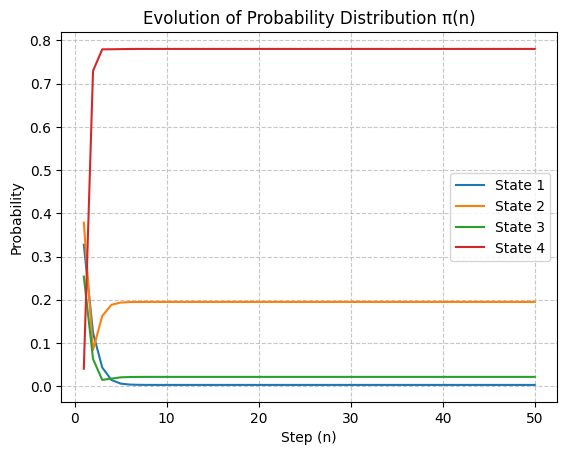

[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Réllena las dos siguientes líneas para generar un pi_sup_1 aleatorio válido. Una idea es generar cada componente de una U(0,1) y luego normalizar para que las componentes sumen 1.
pi_sup_1_sin_normalizar = np.random.uniform(0, 1, P.shape[0])  # esta funcion genera 4 números aleatorios entre 0 y 1
pi_sup_1 = pi_sup_1_sin_normalizar / pi_sup_1_sin_normalizar.sum()             # normaliza para que sumen 1

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs, recordar diapositivas 89 y 90, vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede. Primero vamos a ver cómo podemos representar visualmente una matriz. Una manera habitual es mediante un "heatmap" (mapa de calor). A continuación se realiza dicho gráfico para la MC anterior (mira el gráfico y entiéndelom en particular el código de color):

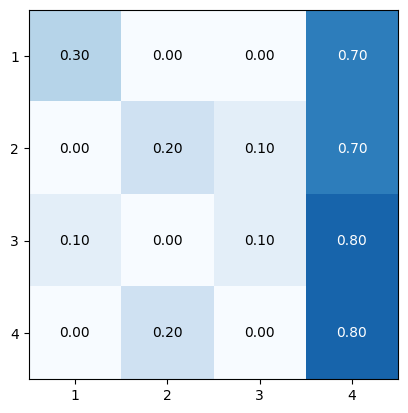

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Completa la siguiente celda para ver la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Comprueba que, efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$. (Recuerda que parecía estabilizarse en [0.00309598 0.19504644 0.02167183 0.78018576]).

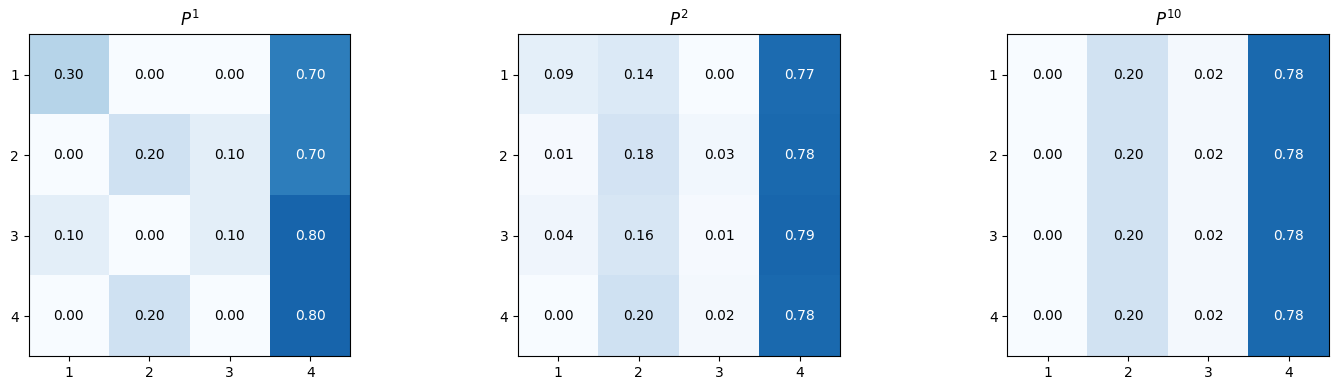

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn = np.linalg.matrix_power(P, n)


    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vamos ahora a mirar el segundo punto de esta sección. Vamos a mirar una MC que sea periódica. Comprueba que la siguiente MC es periódica (¿cuál es el periodo de todos sus estados?):

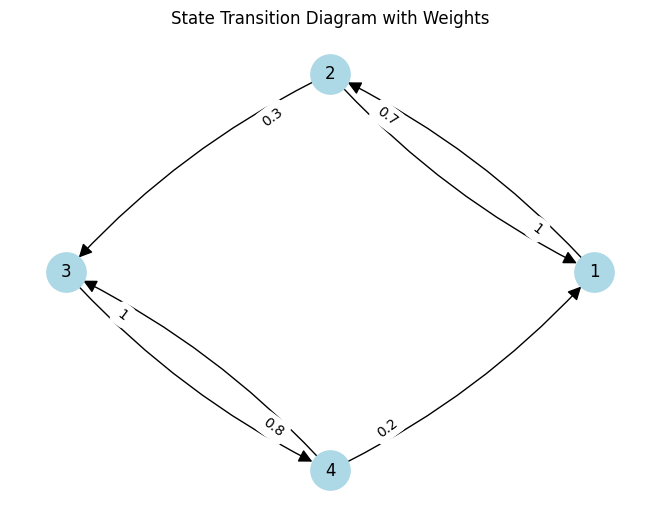

In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes tres celdas se usa la función "visualizar_evolucion_marginal" para ver la evolución de la marginal para tres distribuciones iniciales diferentes. En cada celda, también se imprime por pantalla la marginal en el paso $50$:

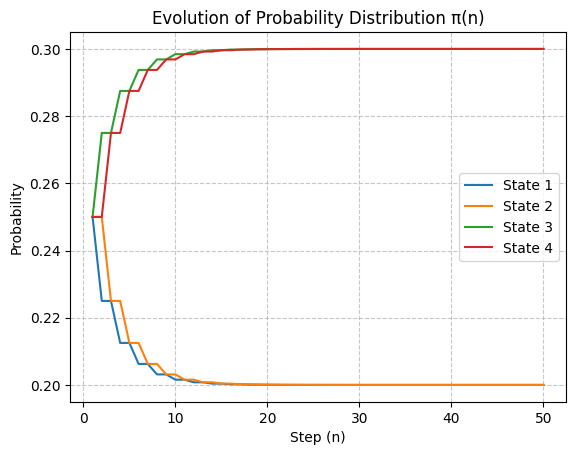

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

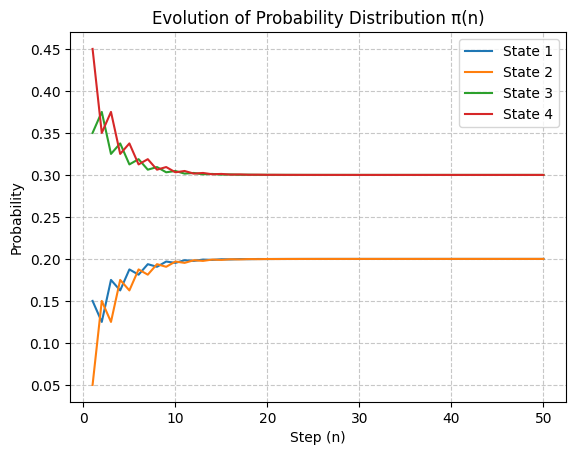

[0.2 0.2 0.3 0.3]


In [ ]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

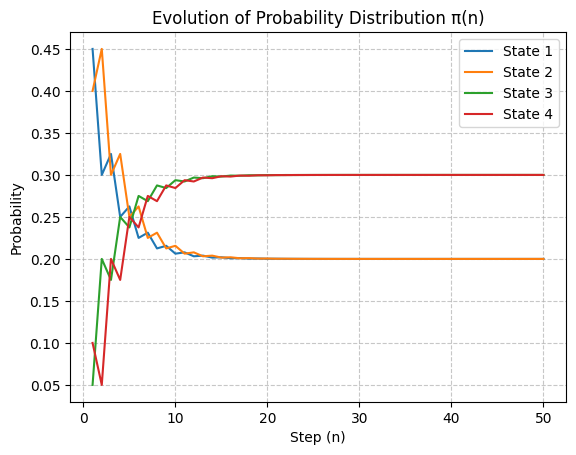

[0.20000001 0.20000001 0.29999999 0.29999999]


In [ ]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Observa que, en los tres casos, parece producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3]. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales. ¿Contradice esto el resultado enunciado en la diapositiva 96?

Para mostrar que no lo contradice, propón en la siguiente celda una distribución inicial para la que no haya convergencia (y visualízalo):

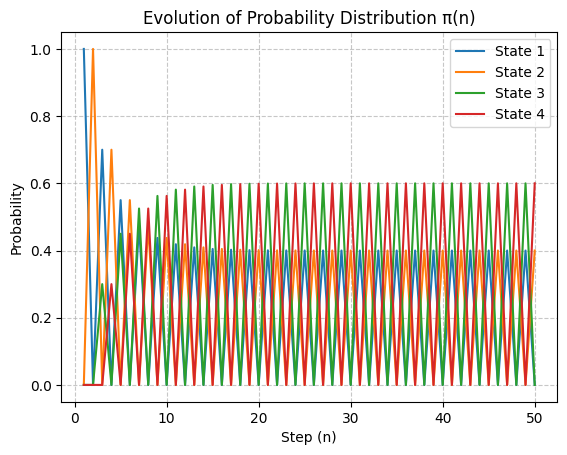

[0.         0.40000004 0.         0.59999996]


In [ ]:

# Por como es la matriz P bastará poner "todo el peso" en el primer que tiene probabilidad 1 de ir al segundo para ver el comportamiento periódico
pi_sup_1 = np.array([1.0, 0.0, 0.0, 0.0])

visualizar_evolucion_marginal(P, pi_sup_1, 50)
#como las líneas no se vuelven horizontales, sino que oscilan podemos ver que no converge bajo esta distribución inicial

# Imprimimos la marginal en el paso 50
print(obtener_marginal(P, pi_sup_1, 50))

Vamos a mirar el tercer y último punto de esta sección. En la siguiente celda, vamos a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.



In [ ]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:

  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:

  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """

  # Paso 1: simulo n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

  # Paso 2: compara cada item del array anterior con cada uno de los estados i=1,...,m.
  m = pi_sup_1.shape[0]
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k) contenga True/False según si el ítem (j,k) del array "trayectorias" es igual a "i" (True) o no lo es (False).
  # Para hacer eso eficientemente, usa el broadcasting de numpy.
  # Creamos un vector con los posibles estados
  # Organizamos los estados con forma (m,1,1) para aplicar broadcasting al compararlos simultáneamente con todas las trayectorias.
  estados = np.arange(m).reshape(m, 1, 1)

  is_equal_bool = (estados == trayectorias)
  # is_equal_bool es un array de forma (m, n_samples, n_steps) donde, para cada trayectoria i y cada paso j,
  # tenemos un vector de tamaño m con true en el estado correspondiente a en el que se encuentra en ese paso y en esa trayectoria
  # será false en el resto de estados. En cada (i,j) hay exactamente un True que indica el estado actual.


  # Paso 3:
  #Media sobre la dimensión de "n_samples"
  # Al hacer la media de booleanos, True cuenta como 1 y False como 0
  # Al hacer la media sobre axis=1 (trayectorias), estamos trabajando con la proporción de trayectorias en las que ha salido cada estado en cada paso
  props = np.mean(is_equal_bool, axis=1) # Resultado: (m, n_steps) proporción de cada estado en cada paso

  return props


Utiliza la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Vamos a hacer la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección. Para ello, rellena la siguiente celda:

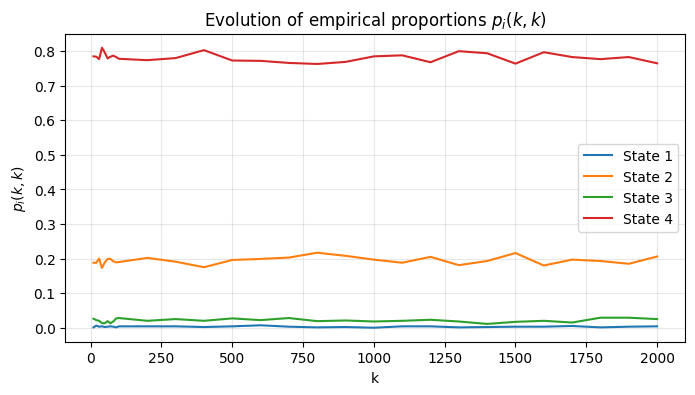

[0.004 0.206 0.025 0.765]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [ ]:
# Definimos la MC (nada que completar aquí)
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0] # m es el número de estados

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000 (nada que completar aquí)
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)). (Nótese que len(grid) no es más que la longitud del grid).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
  n_samples=1000
  n_steps=grid[j]
  props_plot[:, j] = proporciones_empiricas_hasta_cierto_paso(1000, grid[j], P, pi_sup_1)[:, -1]
  #proporciones empíricas hasta cierto paso: las entradas son las probabilidades de que esté en el estado iésimo (cada fila es uno de los estados)
  # en el paso j-ésimo (cada columna un paso)
  #como solo nos interesan las probabilidades de cada estado en el paso j-ésimo precisamente
  #cuando generamos proporciones_empiricas_hasta_cierto_paso nos interesa sólo el último que es el que estamos moviendo con grid[j], por lo que ponemos [:,-1] para quedarnos con la última columna

# A continuación se hace el gráfico.
plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )


## 5. Teorema ergódico

En esta sección vamos a verificar empíricamente el teorema ergódico para algunas MCs.

Recuerda que el teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  



In [ ]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.

  Input:
  n_steps: paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:
  frecuencias_hasta_cierto_paso: frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps. Array con shape (m, n_steps)
  """

  # Paso 1: simular 1 trayectoria para la MC, hasta el paso n_steps
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps) # (1, n_steps)

  # Paso 2: comparar con los m estados usando broadcasting
  m = P.shape[0]
  # Creamos un vector de estados (m, 1) para comparar con la trayectoria (1, n_steps)
  is_equal_bool = (np.arange(m).reshape(m, 1) == trayectoria) # (m, n_steps)

  # Paso 3: Obtener visitas acumuladas con np.cumsum
  # axis=1 indica que sumamos a lo largo de los pasos de tiempo para cada estado
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1) # (m, n_steps), como antes true=1, false=0

  # Paso 4: Calcular frecuencias dividiendo por el índice del paso n=1, 2, ..., n_steps
  # Usamos broadcasting para dividir la matriz de recuentos por el vector de pasos
  pasos = np.arange(1, n_steps + 1)
  frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / pasos # (m, n_steps)

  return frecuencias_hasta_cierto_paso    # (m, n_steps)
  #la fila iésima es la frecuencia en el paso j-ésimo de ese estado


Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

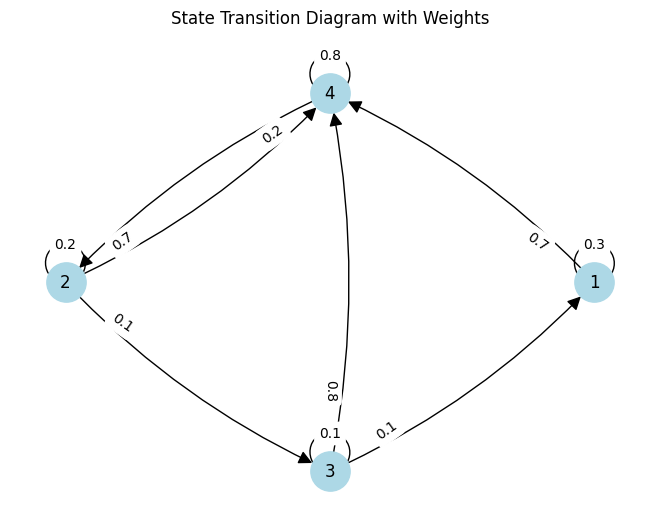

In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

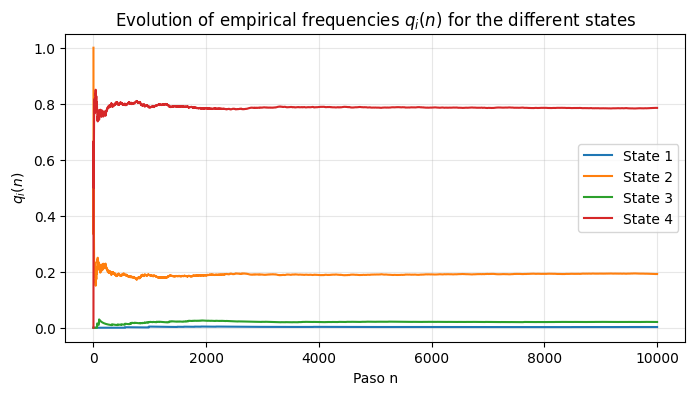

[0.0025 0.1919 0.0205 0.7851]


In [ ]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  #Usamos frecs[i, :] para graficar toda la fila del estado i
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")

# Configuración del gráfico
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Imprimimos los valores finales para comparar con la distribución estacionaria
print(frecs[:, -1])

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

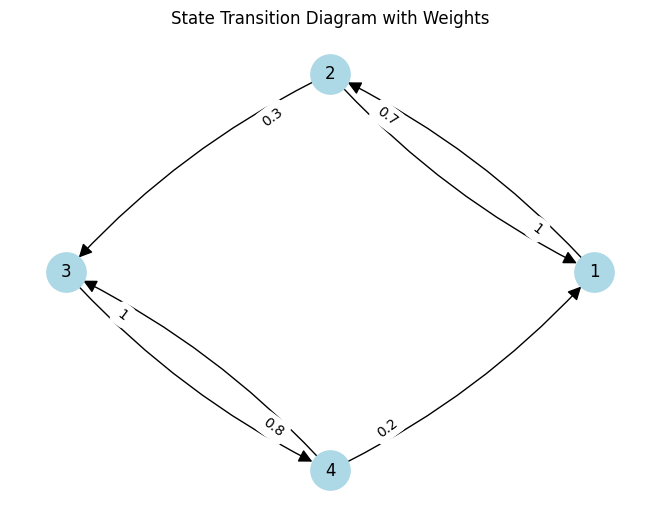

In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

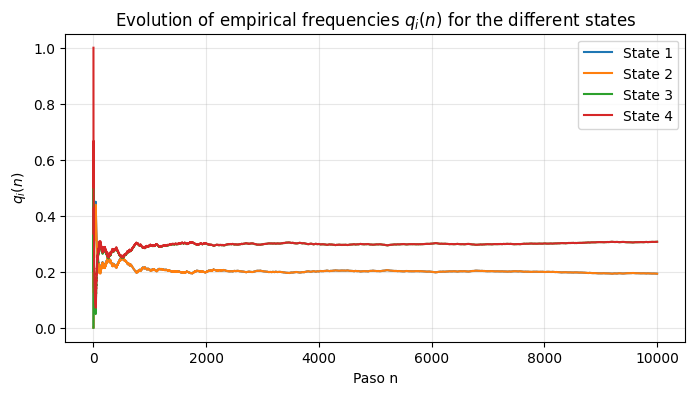

[0.193 0.193 0.307 0.307]


In [ ]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

# Obtenemos la matriz de frecuencias acumuladas q_i(n)
# Esta función simula una única trayectoria y calcula la proporción de tiempo en cada estado
frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)

plt.figure(figsize=(8, 4))
for i in range(m):
  # Graficamos la evolución temporal del estado i (toda la fila)
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Resultado final de la trayectoria en el paso 10000
print(frecs[:,-1])

Esto converge al valor esperado. En efecto, recuerda de la sección 4 que la única distribución estacionaria de esta MC venía dada por: [0.2, 0.2, 0.3, 0.3].